# Calibration of Tumor Growth Models

This notebook fits (calibrates) seven classical tumor growth laws
to volume x time curves from several mice, compares
the models using statistical criteria, and also tests the **ability to predict
the last points** of each curve.

It was written to be read **from top to bottom**: each explanation block
comes right before the code block it describes. Run the cells in order.

## What the notebook does, in 6 steps

1. **Reads the data** for each group (one folder per group).
2. **Defines 7 growth models** (equations for the rate $dT/dt$).
3. **Calibrates each model** *globally*: the biological parameters are
   shared across all mice in the group, but each mouse has its
   own initial volume $T_0$.
4. **Compares the models** using BIC, AIC, AICc, RMSE, correlations, etc.
5. **Tests prediction** by removing the last point of each curve and trying
   to predict it (*last-point* validation).
6. **Saves** a table, a report, parameters, and a figure for each group.


## 1. Libraries we'll use

- **numpy / pandas**: numerical computations and tables.
- **scipy.integrate.solve_ivp**: solves the differential equations (the models' ODEs).
- **scipy.optimize.minimize**: finds the parameters that best fit the data.
- **matplotlib**: plots.
- **tqdm**: progress bar.


In [1]:
from pathlib import Path        # filesystem paths
import math                     # basic math functions
import re                       # regular expressions (file/folder name matching)
import warnings                 # to silence noisy ODE-solver warnings

import numpy as np              # numerical arrays
import pandas as pd             # tables (DataFrames)
import matplotlib.pyplot as plt # plotting
from scipy.integrate import solve_ivp   # numerical ODE solver
from scipy.optimize import minimize     # numerical optimizer (parameter fitting)
from tqdm import tqdm           # progress bar for loops


## 2. Configuration

Two things live here:

### (a) Where the data is and how it's named
The project always follows **the same convention** (don't change this, or it breaks):

```
<root_folder>/
├── data_figB/
│   ├── data_frosberg19_fig3B_NOG_CTRL_1.csv
│   ├── data_frosberg19_fig3B_NOG_CTRL_2.csv
│   └── ...
├── data_figC/
│   └── ...
└── data_figD/
    └── ...
```

- Each **group** is a folder whose name matches `data_figX` (B, C, D, ...).
- Each **mouse** is a `.csv` file with two columns: time and volume.
- The file name follows `..._fig3<PANEL>_<GROUP>_<number>.csv`.

To use **other data** (e.g., CAR-T), keep this same structure and change
**only** `FILE_GLOB` to match the label of your files. Everything else stays the same.

### (b) Speed vs. robustness knobs
If it's taking too long, **decrease** `MULTISTART_N_STARTS` and `OPT_MAXITER`.
If you want a more careful (and slower) fit, increase them.


In [2]:
# === (a) DATA: keep the SAME folder/file convention ===
DATA_ROOT   = None                 # None = auto-detect the folder that contains data_figX
FOLDER_REGEX = r"data_fig[A-Z]+"   # group FOLDER naming convention (do not change)
FILE_GLOB    = "data_frosberg19_fig3*_NOG_CTRL_*.csv"   # <-- CHANGE ONLY THIS for other data
# Example for CAR-T (after naming your files with the same convention):
#   FILE_GLOB = "data_frosberg19_fig3*_NOG_CART_*.csv"

# Captures (panel, mouse number) from the file name, for sorting.
# Works for CTRL, CART, or any label, as long as the name ends in _<n>.csv
SORT_REGEX = r"fig3([A-Z])_.*?_([0-9]+)\.csv$"

# === (b) ROBUSTNESS vs. SPEED ===
# The values below prioritize a careful fit (can take a few minutes).
# If you want to run faster for testing, DECREASE these three numbers.
MULTISTART_N_STARTS = 6     # initial guesses per model (more = more robust and slower)
OPT_MAXITER         = 250   # maximum optimizer iterations
VALIDATION_TOP_K    = 3     # test prediction on the K best models
USE_LAST_POINT_VALIDATION = True

# === General options ===
COUNT_T0_IN_AIC_BIC = True  # count the T0's (1 per mouse) in the model's complexity
OUTPUT_DIRNAME = "calibration_outputs_didactic"
RANDOM_SEED = 42
MODEL_SELECTION_METRIC = "BIC"   # main criterion used to choose the model
BOUNDARY_TOL_REL = 0.02
T0_BOUND_FRACTION_LOW  = 0.10    # T0 can range from 10% ...
T0_BOUND_FRACTION_HIGH = 4.0     # ... to 4x the first observed volume
T0_BOUND_BUFFER = 0.0

MODELS = [
    "bertalanffy",
    "exponential",
    "gompertz",
    "linear",
    "logistic",
    "mendelsohn",
    "surface",
]


## 3. Reading and checking the data

Three simple functions:

- `read_time_volume_file`: reads a single mouse's `.csv`. It's lenient: it accepts
  comma, semicolon, or whitespace as a separator, ignores headers and lines
  starting with `#`, and uses only the first two columns (time and volume). It returns a
  table with columns `t` (time) and `V` (volume), sorted by time.
- `validate_datasets`: checks the basics (>= 3 points, increasing times, positive
  volumes). If something is wrong, it raises a clear error message — better to fail
  early than to calibrate garbage.
- `find_data_root` + `load_data_by_folder`: find the root folder and load each
  group (`data_figX`) using the `FILE_GLOB` you configured.


In [3]:
def read_time_volume_file(filepath):
    '''Reads a single mouse's file and returns a DataFrame with columns t, V.'''
    with open(filepath, "r", encoding="utf-8") as f:
        sample = "".join(f.readlines()[:10])
    sep = r"[;,]" if re.search(r"[;,]", sample) else r"\s+"
    df = pd.read_csv(
        filepath, header=None, names=["t", "V"], sep=sep, engine="python",
        comment="#", skip_blank_lines=True, skipinitialspace=True, usecols=[0, 1],
    )
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df["V"] = pd.to_numeric(df["V"], errors="coerce")
    df = df.dropna(subset=["t", "V"]).copy()
    df = df.sort_values("t").reset_index(drop=True)
    return df


def validate_datasets(datasets, filepaths):
    '''Checks minimum requirements for each mouse.'''
    for i, (df, fp) in enumerate(zip(datasets, filepaths), start=1):
        t_obs = df["t"].to_numpy(float)
        v_obs = df["V"].to_numpy(float)
        if len(t_obs) < 3:
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has fewer than 3 observations.")
        if np.any(t_obs < 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has negative time values.")
        if np.any(v_obs <= 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has non-positive volumes.")
        if np.any(np.diff(t_obs) <= 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) must have strictly increasing times.")


def sort_files(filepaths):
    '''Sorts files by (panel, mouse number) extracted from the file name.'''
    def keys(path):
        m = re.search(SORT_REGEX, Path(path).name)
        if m:
            return (m.group(1), int(m.group(2)))
        return ("Z", 10**9)
    return sorted(filepaths, key=keys)


def find_data_root():
    '''Looks for the folder that contains data_figX subfolders.'''
    candidates = [Path.cwd(), Path.cwd() / "data"]
    seen, unique = set(), []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p); unique.append(p)
    for root in unique:
        if root.exists() and root.is_dir() and any(
            c.is_dir() and re.fullmatch(FOLDER_REGEX, c.name) for c in root.iterdir()
        ):
            return root
    checked = ", ".join(str(p) for p in unique)
    raise FileNotFoundError(
        f"Could not find any folders matching {FOLDER_REGEX}. Checked locations: {checked}"
    )


def load_data_by_folder(data_root=None):
    '''Loads each group (data_figX folder) using the configured FILE_GLOB.'''
    data_root = find_data_root() if data_root is None else Path(data_root)
    if not data_root.exists():
        raise FileNotFoundError(f"Data folder not found: {data_root}")
    grouped = {}
    folders = sorted(p for p in data_root.iterdir()
                     if p.is_dir() and re.fullmatch(FOLDER_REGEX, p.name))
    for folder in folders:
        filepaths = [str(fp) for fp in folder.glob(FILE_GLOB) if fp.is_file()]
        if not filepaths:
            continue
        filepaths = sort_files(filepaths)
        datasets = [read_time_volume_file(fp) for fp in filepaths]
        validate_datasets(datasets, filepaths)
        grouped[folder.name] = {"filepaths": filepaths, "datasets": datasets}
    if not grouped:
        raise FileNotFoundError(
            f"No files matching '{FILE_GLOB}' were found inside the folders under {data_root}"
        )
    return grouped


Let's **load the data and take a look** at what came in. This also works
as a quick test: if the configuration is wrong, the error will show up here.


In [4]:
data_root = find_data_root() if DATA_ROOT is None else Path(DATA_ROOT)
grouped_data = load_data_by_folder(data_root)

print(f"Detected root folder: {data_root}\n")
for group_name, gd in grouped_data.items():
    print(f"Group '{group_name}': {len(gd['datasets'])} mouse/mice")
    for fp, df in zip(gd["filepaths"], gd["datasets"]):
        print(f"   {Path(fp).name:45s} n={len(df):2d}  "
              f"t∈[{df['t'].min():.1f},{df['t'].max():.1f}]  "
              f"V∈[{df['V'].min():.3g},{df['V'].max():.3g}]")
    print()


Detected root folder: C:\Users\power\OneDrive\Bureau\CESI\Cancer site\notebooks_calibracao_NBA

Group 'data_figB': 2 mouse/mice
   data_frosberg19_fig3B_NOG_CTRL_1.csv          n=15  t∈[0.8,51.2]  V∈[2.1,601]
   data_frosberg19_fig3B_NOG_CTRL_2.csv          n=15  t∈[0.8,51.2]  V∈[2.1,573]

Group 'data_figC': 5 mouse/mice
   data_frosberg19_fig3C_NOG_CTRL_1.csv          n=13  t∈[12.8,103.1]  V∈[0.509,167]
   data_frosberg19_fig3C_NOG_CTRL_2.csv          n=13  t∈[13.0,103.1]  V∈[0.509,158]
   data_frosberg19_fig3C_NOG_CTRL_3.csv          n=13  t∈[12.8,103.1]  V∈[0.509,118]
   data_frosberg19_fig3C_NOG_CTRL_4.csv          n=13  t∈[13.0,103.0]  V∈[0.509,81.4]
   data_frosberg19_fig3C_NOG_CTRL_5.csv          n=13  t∈[13.0,103.1]  V∈[0.065,72.3]

Group 'data_figD': 6 mouse/mice
   data_frosberg19_fig3D_NOG_CTRL_1.csv          n=19  t∈[13.1,143.0]  V∈[0.061,342]
   data_frosberg19_fig3D_NOG_CTRL_2.csv          n=19  t∈[13.1,142.8]  V∈[0.061,289]
   data_frosberg19_fig3D_NOG_CTRL_3.csv        

## 4. The 7 growth models

Each model is a formula for the tumor's **growth rate**,
$\dfrac{dT}{dt}$, where $T$ is the volume and $t$ is time. The idea: starting
from an initial volume $T_0$, the ODE "tells" us how the tumor evolves.

| Model | $dT/dt$ | Intuition |
|---|---|---|
| **exponential** | $r\,T$ | free growth, no brake (always increasing) |
| **mendelsohn** | $r\,T^{b}$ | exponential "deformed" by the exponent $b$ |
| **logistic** | $r\,T\,(1 - T/K)$ | grows and **saturates** at a carrying capacity $K$ |
| **bertalanffy** | $r\,T^{2/3} - \alpha\,T$ | gain via surface area minus proportional loss |
| **gompertz** | $r\,T\,\ln(K/(T+c))$ | saturates at $K$, typical tumor deceleration |
| **linear** | $r\,T/(T+f)$ | nearly constant rate once $T$ is large |
| **surface** | $r\,T/(T+f)^{1/3}$ | growth limited by surface area |

> **Important:** these are **growth-only** models — they are monotonic (exponential
> only increases; logistic/Gompertz increase and then plateau). They describe the
> **untreated (control)** group well. If a group **responds** to treatment and the
> tumor **regresses** (goes up and then down), none of these laws can reproduce
> that decline. In that case, a model with a **treatment term** would be needed
> (a subject for a later stage).

The `safe_positive` / `safe_power` functions are just numerical safeguards to avoid
taking the log of zero, overflow, etc.


In [5]:
def safe_positive(x, lower=1e-12, upper=1e12):
    '''Clips a value to a safe positive range, to avoid log(0), overflow, etc.'''
    return float(np.clip(x, lower, upper))


def safe_power(base, exponent):
    '''Computes base**exponent via exp(exponent * log(base)), safely clipped.'''
    base = safe_positive(base)
    val = np.exp(np.clip(float(exponent) * np.log(base), -700, 700))
    return float(np.clip(val, 1e-300, 1e300))


def growth_term(t, T, params, model):
    '''Returns dT/dt for the chosen model.'''
    T = safe_positive(T)
    if model == "exponential":
        return params["r"] * T
    if model == "mendelsohn":
        return params["r"] * safe_power(T, params["b"])
    if model == "logistic":
        K = safe_positive(params["K"])
        return params["r"] * T * (1 - T / K)
    if model == "bertalanffy":
        return params["r"] * safe_power(T, 2 / 3) - params["alpha"] * T
    if model == "gompertz":
        K = safe_positive(params["K"]); c = max(float(params["c"]), 0.0)
        return params["r"] * T * np.log(K / safe_positive(T + c))
    if model == "linear":
        f = safe_positive(params["f"])
        return params["r"] * T / (T + f)
    if model == "surface":
        f = safe_positive(params["f"])
        return params["r"] * T / safe_power(T + f, 1 / 3)
    raise ValueError(f"Unknown model: {model}")


def rhs_growth_only(t, y, params, model):
    '''Right-hand side of the ODE, in the format expected by solve_ivp.'''
    return [growth_term(t, y[0], params, model)]


### 4.1 Simulating a curve

Given $T_0$ and the parameters, `simulate_growth` computes the predicted volume at
the requested time points. The **exponential** model has a closed-form solution
($T_0 e^{rt}$, instantaneous). The others are solved numerically with `solve_ivp`
(it first tries the `LSODA` solver; if that fails, it falls back to `RK45`).


In [6]:
def simulate_growth(t_eval, T0, params, model):
    '''Returns (times, predicted_volumes) at the times given in t_eval.'''
    t_eval = np.asarray(t_eval, dtype=float)

    if model == "exponential":   # closed-form solution (fast and exact)
        dt = t_eval - t_eval[0]
        y = float(T0) * np.exp(np.clip(float(params["r"]) * dt, -700, 700))
        if np.any(~np.isfinite(y)) or np.any(y <= 0):
            raise RuntimeError("Invalid exponential solution.")
        return t_eval, y

    for method, rtol, atol in [("LSODA", 1e-5, 1e-7), ("RK45", 1e-4, 1e-6)]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sol = solve_ivp(
                fun=lambda t, y: rhs_growth_only(t, y, params, model),
                t_span=(float(t_eval[0]), float(t_eval[-1])),
                y0=[float(T0)], t_eval=t_eval, method=method, rtol=rtol, atol=atol,
            )
        if sol.success:
            y = sol.y[0]
            if np.all(np.isfinite(y)) and np.all(y > 0):
                return sol.t, y
    raise RuntimeError("ODE integration failed with every available solver.")


## 5. Initial guesses and bounds for each parameter

For the optimizer to work well, we give it a reasonable **initial guess** and
**bounds** (min/max) for each parameter. `get_model_spec` computes this
automatically from the scale of your data (maximum volume, median, experiment
duration). This way the notebook adapts on its own to data at any
scale.

`get_t0_bounds` defines the range for each mouse's initial volume $T_0$
(by default, from 10% to 4x the first measured volume).


In [7]:
def get_global_scales(volume_arrays, time_arrays):
    '''Computes overall scale statistics (max/min/median volume, time span, typical rate).'''
    all_v = np.concatenate(volume_arrays); all_t = np.concatenate(time_arrays)
    vmax = float(np.max(all_v)); vmin = float(np.min(all_v)); vmed = float(np.median(all_v))
    tspan = max(float(np.max(all_t)) - float(np.min(all_t)), 1e-6)
    typical_rate = max((vmax - vmin) / tspan, 1e-3)
    return {"vmax": vmax, "vmin": vmin, "vmed": vmed, "tspan": tspan,
            "typical_rate": typical_rate}


def get_model_spec(model_name, volume_arrays, time_arrays):
    '''Number of parameters, initial guess, bounds, and how to convert vector -> dict.'''
    s = get_global_scales(volume_arrays, time_arrays)
    vmax = s["vmax"]; vmed = max(s["vmed"], 1.0); tspan = s["tspan"]
    rate_scale = max(s["typical_rate"], 1e-3)

    if model_name == "exponential":
        return {"n_shared": 1, "shared_names": ["r"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan)]),
                "bounds_shared": [(0.0, 0.5)],
                "shared_to_params": lambda x: {"r": x[0]}}
    if model_name == "mendelsohn":
        return {"n_shared": 2, "shared_names": ["r", "b"],
                "x0_shared": np.array([min(0.05, 1.0 / tspan), 1.0]),
                "bounds_shared": [(0.0, 0.5), (0.25, 1.75)],
                "shared_to_params": lambda x: {"r": x[0], "b": x[1]}}
    if model_name == "logistic":
        return {"n_shared": 2, "shared_names": ["r", "K"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan), max(1.2 * vmax, 10.0)]),
                "bounds_shared": [(0.0, 0.5), (1.01 * vmax, max(20.0 * vmax, 10.0))],
                "shared_to_params": lambda x: {"r": x[0], "K": x[1]}}
    if model_name == "bertalanffy":
        return {"n_shared": 2, "shared_names": ["r", "alpha"],
                "x0_shared": np.array([min(2.0, max(0.2, rate_scale / (vmed ** (2/3)))), 0.02]),
                "bounds_shared": [(0.0, 5.0), (0.0, 1.0)],
                "shared_to_params": lambda x: {"r": x[0], "alpha": x[1]}}
    if model_name == "gompertz":
        return {"n_shared": 3, "shared_names": ["r", "K", "c"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan), max(1.2 * vmax, 10.0), 0.5 * vmed]),
                "bounds_shared": [(0.0, 0.5), (1.01 * vmax, max(25.0 * vmax, 10.0)),
                                  (0.0, max(10.0 * vmed, vmax))],
                "shared_to_params": lambda x: {"r": x[0], "K": x[1], "c": x[2]}}
    if model_name in ("linear", "surface"):
        return {"n_shared": 2, "shared_names": ["r", "f"],
                "x0_shared": np.array([max(rate_scale, 0.1), max(vmed, 1.0)]),
                "bounds_shared": [(0.0, max(20.0 * rate_scale, 10.0)),
                                  (1e-6, max(20.0 * vmax, 10.0))],
                "shared_to_params": lambda x: {"r": x[0], "f": x[1]}}
    raise ValueError(f"Unknown model: {model_name}")


def get_t0_bounds(volume_arrays):
    '''Initial guess and bounds for each mouse's initial volume T0.'''
    guesses, bounds = [], []
    for v in volume_arrays:
        v0 = float(v[0])
        lo = max(1e-6, T0_BOUND_FRACTION_LOW * v0)
        hi = max(v0 * (1.0 + T0_BOUND_BUFFER), T0_BOUND_FRACTION_HIGH * v0)
        guesses.append(v0); bounds.append((lo, hi))
    return np.array(guesses, dtype=float), bounds


## 6. How we find the best parameters (calibration)

**Global calibration.** The vector of unknowns is

$$\theta = [\underbrace{\text{model parameters}}_{\text{same for all mice}},\;
T_{0,1}, T_{0,2}, \dots, T_{0,n}]$$

that is, **one set of biological parameters** for the whole group + **one $T_0$
per mouse**. This assumes the animals follow the same biology, differing
only in their initial size.

**Objective function.** For a candidate $\theta$, we simulate every mouse and
sum the squared error between predicted and observed values. The optimizer
(`L-BFGS-B`) searches for the $\theta$ that **minimizes** this error.

**Multistart.** The optimizer can get stuck in a bad "valley" (a local minimum).
To avoid this, we try several starting points (`MULTISTART_N_STARTS`) and keep
the best one. ⚡ *This is the main speed knob: fewer starting points = faster.*


In [8]:
def clip_to_bounds(x, bounds):
    '''Clips each entry of x into its corresponding (lo, hi) bound.'''
    x = np.asarray(x, dtype=float).copy()
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x


def sample_param_within_bounds(rng, lo, hi):
    '''Draws a random value within [lo, hi], in log-space if the range is very wide.'''
    if lo <= 0:
        return rng.uniform(lo, hi)
    if hi / max(lo, 1e-12) >= 50:          # very wide range -> sample in log-space
        return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
    return rng.uniform(lo, hi)


def generate_starting_points(base_x0, bounds, n_starts, rng):
    '''Builds a list of distinct starting points for the multistart optimization:
    the base guess itself, a few scaled versions of it, and random samples
    within the bounds, until we have n_starts unique points.'''
    starts = [clip_to_bounds(base_x0, bounds)]
    base = np.asarray(base_x0, dtype=float)
    for m in [0.5, 0.8, 1.2, 1.5]:
        if len(starts) >= n_starts:
            break
        starts.append(clip_to_bounds(base * m, bounds))
    while len(starts) < n_starts:
        trial = np.array([sample_param_within_bounds(rng, lo, hi) for lo, hi in bounds])
        starts.append(clip_to_bounds(trial, bounds))
    seen, deduped = set(), []
    for x in starts:
        key = tuple(np.round(x, 10))
        if key not in seen:
            seen.add(key); deduped.append(x)
    return deduped


def objective_factory(model_name, t_list, v_list, n_shared, shared_to_params):
    '''Builds the objective function (mean squared error across all mice) for a given model.'''
    big_penalty = 1e18
    def objective(theta):
        shared = theta[:n_shared]; T0_vec = theta[n_shared:]
        try:
            params = shared_to_params(shared)
            sqerr_total, n_total = 0.0, 0
            for t_obs, v_obs, T0_i in zip(t_list, v_list, T0_vec):
                if T0_i <= 0 or not np.isfinite(T0_i):
                    return big_penalty
                _, v_hat = simulate_growth(t_obs, T0_i, params, model_name)
                if np.any(~np.isfinite(v_hat)) or np.any(v_hat <= 0):
                    return big_penalty
                sqerr_total += float(np.sum((v_hat - v_obs) ** 2)); n_total += len(v_obs)
            return sqerr_total / max(n_total, 1)
        except Exception:
            return big_penalty
    return objective


def multistart_optimize(objective, x0, bounds, rng, n_starts):
    '''Runs L-BFGS-B from several starting points and keeps the best result.'''
    starts = generate_starting_points(x0, bounds, n_starts, rng)
    best_res, successful = None, 0
    for start in starts:
        try:
            res = minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": OPT_MAXITER, "maxfun": 5000, "maxls": 30})
        except Exception:
            continue
        if np.isfinite(res.fun):
            successful += int(bool(res.success))
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    if best_res is None:
        raise RuntimeError("All optimization attempts failed.")
    return best_res, len(starts), successful


## 7. Metrics: how to compare the models

A model can fit better simply because it has more parameters. That's why we use
**information criteria** that penalize complexity:

- **BIC** (main criterion) $= k\ln(n) - 2\,\text{LL}$ — **lower is better**.
- **AIC** and **AICc** (AIC corrected for small $n$) — same idea.
- $k$ = number of parameters, $n$ = number of observations, LL = log-likelihood.

And **goodness-of-fit** metrics: RMSE, MAE, WAPE/sMAPE (stable percentage
errors), and the PCC/CCC/ICC correlation/agreement measures (closer to 1 is better).


In [9]:
# --- Information criteria (lower = better; they penalize model complexity) ---
def aic_from_ll(ll, k):            return 2 * k - 2 * ll
def bic_from_ll(ll, k, n):         return k * np.log(n) - 2 * ll
def aicc_from_aic(aic, k, n):
    d = n - k - 1
    return aic + (2 * k * (k + 1)) / d if d > 0 else np.nan

def loglik_gaussian(y, yhat):
    '''Gaussian log-likelihood of the residuals (used to compute AIC/BIC).'''
    resid = np.asarray(y, float) - np.asarray(yhat, float)
    var = max(np.var(resid, ddof=1) if len(resid) > 1 else np.var(resid), 1e-12)
    return -0.5 * np.sum(resid ** 2 / var + np.log(2 * np.pi) + np.log(var))

# --- Goodness-of-fit metrics (in the same units as the data, mm^3) ---
def rmse(y, yhat):
    '''Root Mean Squared Error.'''
    return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yhat,float))**2)))

def mae(y, yhat):
    '''Mean Absolute Error.'''
    return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yhat,float))))

def wape(y, yhat):
    '''Weighted Absolute Percentage Error: normalized by the total observed volume.
    Unlike sMAPE, it stays well-behaved even when individual values are near zero.'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float); d = np.sum(np.abs(y))
    return float(100*np.sum(np.abs(y-yhat))/d) if d > 0 else np.nan

def smape(y, yhat):
    '''Symmetric Mean Absolute Percentage Error (can blow up when y and yhat
    are both close to zero — use WAPE instead for that regime).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    d = np.where(np.abs(y)+np.abs(yhat) <= 1e-12, 1e-12, np.abs(y)+np.abs(yhat))
    return float(100*np.mean(2*np.abs(y-yhat)/d))

# --- Correlation / agreement metrics (closer to 1 = better agreement) ---
def pcc(y, yhat):
    '''Pearson correlation coefficient: measures linear association only,
    not whether predictions match the observed scale (can be high even with bias).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    return np.corrcoef(y, yhat)[0, 1] if len(y) >= 2 else np.nan

def ccc(y, yhat):
    '''Lin's Concordance Correlation Coefficient: correlation combined with a
    penalty for bias and scale mismatch. Stricter than PCC; a better measure
    of true agreement between predicted and observed values.'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    cov = np.cov(y, yhat, ddof=1)[0, 1]
    d = np.var(y,ddof=1) + np.var(yhat,ddof=1) + (np.mean(y)-np.mean(yhat))**2
    return (2*cov)/d if d > 0 else np.nan

def icc_a1(y, yhat):
    '''Intraclass correlation coefficient (absolute-agreement, one-way ANOVA form).
    Conceptually close to CCC; typically gives very similar values in practice.'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    X = np.column_stack([y, yhat]); n, k = X.shape
    mr = np.mean(X,1,keepdims=True); mc = np.mean(X,0,keepdims=True); gm = np.mean(X)
    ss_r = k*np.sum((mr-gm)**2); ss_c = n*np.sum((mc-gm)**2)
    ss_e = np.sum((X-mr-mc+gm)**2)
    df_r, df_c, df_e = n-1, k-1, (n-1)*(k-1)
    if df_r <= 0 or df_e <= 0: return np.nan
    ms_r = ss_r/df_r; ms_c = ss_c/df_c if df_c > 0 else 0.0; ms_e = ss_e/df_e
    den = ms_r + (k-1)*ms_e + (k*(ms_c-ms_e)/n)
    return (ms_r-ms_e)/den if not np.isclose(den, 0) else np.nan

def metrics_from_predictions(y, yhat, k_total):
    '''Bundles all metrics above into a single dict, given k_total estimated parameters.'''
    ll = loglik_gaussian(y, yhat); aic = aic_from_ll(ll, k_total)
    return {"ll": ll, "aic": aic, "aicc": aicc_from_aic(aic, k_total, len(y)),
            "bic": bic_from_ll(ll, k_total, len(y)),
            "mse": float(np.mean((np.asarray(y)-np.asarray(yhat))**2)),
            "rmse": rmse(y,yhat), "mae": mae(y,yhat), "wape": wape(y,yhat),
            "smape": smape(y,yhat), "pcc": pcc(y,yhat), "ccc": ccc(y,yhat),
            "icc": icc_a1(y,yhat), "k_total": k_total}


## 8. Putting it all together: fitting one model to one group

`fit_global_model` runs the full cycle for **one** model in one group:
it builds the $\theta$ vector, optimizes (multistart), simulates the final fit
for each mouse, and computes the metrics. `build_diagnostics` raises warnings
whenever a parameter "touches" its bound (a sign that the model may be poorly
identified by the data).

> 💡 **Speed trick:** `fit_global_model` accepts an `x0_override`
> (a ready-made initial guess) and `n_starts`. We use this during the prediction
> step to **reuse** the parameters already found, instead of searching from
> scratch.


In [10]:
def is_near_bound(value, bound, rel_tol=BOUNDARY_TOL_REL):
    '''Checks whether a fitted value is within rel_tol of its lower or upper bound.'''
    lo, hi = bound
    if not np.isfinite(value) or hi <= lo: return False
    w = hi - lo
    return (value - lo) <= rel_tol*w or (hi - value) <= rel_tol*w


def build_diagnostics(model_name, params_est, T0_list, shared_bounds, t0_bounds, volume_arrays):
    '''Flags parameters that ended up at (or very near) their search bounds,
    plus a few model-specific red flags — these usually mean the parameter is
    poorly identified by the data, not necessarily that the fit is "wrong".'''
    notes = []; max_obs = max(float(np.max(v)) for v in volume_arrays)
    for (name, value), bound in zip(params_est.items(), shared_bounds):
        if is_near_bound(float(value), bound):
            notes.append(f"{name} at bound [{bound[0]:.4g}, {bound[1]:.4g}]")
    for idx, (val, bound) in enumerate(zip(T0_list, t0_bounds), start=1):
        if is_near_bound(float(val), bound):
            notes.append(f"T0_{idx} at bound [{bound[0]:.4g}, {bound[1]:.4g}]")
    if model_name in {"logistic","gompertz"} and params_est.get("K",0.0) > 10*max_obs:
        notes.append("K much larger than observed volumes; saturation poorly identified")
    if model_name in {"linear","surface"} and params_est.get("f",0.0) > 10*max_obs:
        notes.append("f very large; model becomes nearly non-saturating")
    if model_name == "gompertz" and params_est.get("r",0.0) <= 1e-8:
        notes.append("r practically zero")
    if model_name == "mendelsohn":
        b = params_est.get("b", np.nan)
        if np.isfinite(b) and (b < 0.4 or b > 1.6):
            notes.append("b in an extreme region")
    return notes if notes else ["no obvious issues"]


def fit_global_model(model_name, datasets, rng, x0_override=None, n_starts=None):
    '''Full calibration cycle for one model on one group: builds theta, optimizes it
    with multistart, simulates the fitted curve for every mouse, and computes metrics
    and diagnostics.'''
    model_name = model_name.lower()
    if n_starts is None:
        n_starts = MULTISTART_N_STARTS
    t_list = [df["t"].to_numpy(float) for df in datasets]
    v_list = [df["V"].to_numpy(float) for df in datasets]
    n_mice = len(datasets)

    spec = get_model_spec(model_name, v_list, t_list)
    n_shared = spec["n_shared"]
    bounds = spec["bounds_shared"] + list(get_t0_bounds(v_list)[1])
    T0_guess = get_t0_bounds(v_list)[0]
    x0 = np.concatenate([spec["x0_shared"], T0_guess]) if x0_override is None \
         else clip_to_bounds(x0_override, bounds)

    objective = objective_factory(model_name, t_list, v_list, n_shared, spec["shared_to_params"])
    result, n_used, n_ok = multistart_optimize(objective, x0, bounds, rng, n_starts)
    if not np.isfinite(result.fun):
        raise RuntimeError(f"Optimization failed for {model_name}.")

    theta_hat = clip_to_bounds(result.x, bounds)
    shared_hat = theta_hat[:n_shared]; T0_hat = theta_hat[n_shared:]
    params_est = spec["shared_to_params"](shared_hat)

    fits, v_obs_all, v_fit_all = [], [], []
    for i, (t_obs, v_obs, T0_i) in enumerate(zip(t_list, v_list, T0_hat), start=1):
        t_fit, v_fit = simulate_growth(t_obs, T0_i, params_est, model_name)
        fits.append({"mouse": i, "t_obs": t_obs, "V_obs": v_obs,
                     "t_fit": t_fit, "V_fit": v_fit, "T0": T0_i})
        v_obs_all.append(v_obs); v_fit_all.append(v_fit)

    k_total = n_shared + (n_mice if COUNT_T0_IN_AIC_BIC else 0)
    metrics = metrics_from_predictions(np.concatenate(v_obs_all),
                                       np.concatenate(v_fit_all), k_total)
    diag = build_diagnostics(model_name, params_est, T0_hat,
                             spec["bounds_shared"], get_t0_bounds(v_list)[1], v_list)
    return {"model": model_name, "params_est": params_est, "T0_list": T0_hat,
            "theta_hat": theta_hat, "fits_by_mouse": fits, "metrics": metrics,
            "diagnostics": diag,
            "optimization": {"objective": float(result.fun), "success": bool(result.success),
                             "n_starts_used": n_used, "n_successful_starts": n_ok}}


def calibrate_global_model(model_name, datasets, seed):
    '''Convenience wrapper: fits one model with a fresh random seed and no validation yet.'''
    fit = fit_global_model(model_name, datasets, np.random.default_rng(seed))
    fit["validation"] = None
    return fit


## 9. Testing **last-point prediction** (last-point validation)

1. For each mouse, we **hide the last point** of the curve.
2. We calibrate the model using **only the remaining points**.
3. We ask the model to **predict the hidden point** and compare it to the real value.

This measures **predictive capability** (one-step-ahead extrapolation), not just
goodness of fit. This mechanism is **independent of the model and of the group**:
it works the same way for control, CAR-T, or any other data — just point it at the data.

⚡ **Speed:** instead of recalibrating from scratch, we reuse the parameters
already found in the full fit as the initial guess (`x0_override`) and use
few `n_starts`. Same result, much faster. And we only validate the
`VALIDATION_TOP_K` best models.


In [11]:
def build_validation_datasets(datasets):
    '''For each mouse, builds the training set (without the last point) and the hidden point.
    Returns (None, None) if any mouse doesn't have enough points left to train on.'''
    train, holdout = [], []
    for i, df in enumerate(datasets, start=1):
        if len(df) < 4:           # need enough data left over to train on
            return None, None
        train.append(df.iloc[:-1].reset_index(drop=True))
        last = df.iloc[-1]
        holdout.append({"mouse": i, "t": float(last["t"]), "V": float(last["V"])})
    return train, holdout


def evaluate_last_point_validation(model_name, datasets, seed, warm_theta=None):
    '''Refits the model without the last point of each mouse, then predicts that
    point and compares it against the real observed value.'''
    train, holdout = build_validation_datasets(datasets)
    if train is None:
        return None
    # reuse the parameters from the full fit as the initial guess (fast)
    n_starts = 2 if warm_theta is not None else MULTISTART_N_STARTS
    fit = fit_global_model(model_name, train, np.random.default_rng(seed),
                           x0_override=warm_theta, n_starts=n_starts)

    y_true, y_pred, per_mouse = [], [], []
    for mf, h in zip(fit["fits_by_mouse"], holdout):
        t_eval = np.append(np.asarray(mf["t_fit"], float), h["t"])
        _, pred = simulate_growth(t_eval, float(mf["T0"]), fit["params_est"], model_name)
        v_pred = float(pred[-1])
        y_true.append(h["V"]); y_pred.append(v_pred)
        per_mouse.append({"mouse": h["mouse"], "t_holdout": h["t"],
                          "V_true": h["V"], "V_pred": v_pred,
                          "abs_error": abs(v_pred - h["V"])})
    return {"metrics": {"rmse": rmse(y_true,y_pred), "mae": mae(y_true,y_pred),
                        "wape": wape(y_true,y_pred), "smape": smape(y_true,y_pred),
                        "pcc": pcc(y_true,y_pred), "ccc": ccc(y_true,y_pred),
                        "n_holdout": len(y_true)},
            "per_mouse": per_mouse}


def attach_validation_to_top_models(results, datasets, base_seed, top_k=None):
    '''Runs last-point validation only for the top_k models with the lowest BIC
    (to save computation time — validating all 7 models would be much slower).'''
    if top_k is None:
        top_k = VALIDATION_TOP_K
    if not USE_LAST_POINT_VALIDATION or not top_k or top_k <= 0:
        return results
    ranked = sorted(results, key=lambda x: x["metrics"]["bic"])
    selected = {r["model"] for r in ranked[:min(top_k, len(ranked))]}
    for idx, res in enumerate(results):
        if res["model"] not in selected:
            continue
        try:
            res["validation"] = evaluate_last_point_validation(
                res["model"], datasets, base_seed + 10_000 + idx,
                warm_theta=res.get("theta_hat"))
        except Exception as exc:
            res["validation"] = {"error": str(exc)}
    return results


## 10. Summary table, report, and plot

- `build_summary_table`: puts everything together in a table sorted by BIC, with a
  `ΔBIC` column (the difference from the best model). Rule of thumb: $\Delta\text{BIC} < 2$
  means "tie"; $> 10$ is strong evidence against that model.
- `plot_fits`: one panel per mouse, with the data (black dots) and the
  curves for every model; the BIC winner is drawn with a thicker line.
- The report functions save `.txt` and `.csv` files to the output folder.


In [12]:
def build_summary_table(results):
    '''Builds a comparison table across all fitted models, sorted by the chosen
    selection metric (BIC by default), with Delta_BIC / Delta_AICc columns added.'''
    rows = []
    for res in results:
        m = res["metrics"]; val = res.get("validation")
        vm = val.get("metrics") if isinstance(val, dict) and "metrics" in val else None
        rows.append({"model": res["model"], "BIC": m["bic"], "AIC": m["aic"],
                     "AICc": m["aicc"], "LogLik": m["ll"], "RMSE": m["rmse"],
                     "MAE": m["mae"], "WAPE (%)": m["wape"], "sMAPE (%)": m["smape"],
                     "PCC": m["pcc"], "CCC": m["ccc"], "ICC": m["icc"],
                     "CV_RMSE": np.nan if vm is None else vm["rmse"],
                     "CV_MAE":  np.nan if vm is None else vm["mae"],
                     "diagnostics": " | ".join(res["diagnostics"])})
    df = pd.DataFrame(rows).sort_values(MODEL_SELECTION_METRIC).reset_index(drop=True)
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    df["ΔAICc"] = df["AICc"] - df["AICc"].min(skipna=True)
    return df


def sanitize_filename(name):
    '''Turns a group name into a safe file name (letters, digits, _, ., - only).'''
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))

def ensure_output_dir(base):
    '''Creates (if needed) and returns the output folder.'''
    out = Path(base) / OUTPUT_DIRNAME; out.mkdir(parents=True, exist_ok=True); return out

def get_layout(n, max_cols=3):
    '''Computes a (rows, cols) grid layout for n subplots.'''
    if n <= 0: return 1, 1
    c = min(max_cols, n); return math.ceil(n / c), c


def format_group_report(group_name, filepaths, datasets, results, summary_df):
    '''Builds the full plain-text report for one group: file list, comparison
    table, best model, and per-model parameters/diagnostics/validation.'''
    L = ["="*90, f"RESULTS FOR GROUP: {group_name}", "="*90, "", "FILES"]
    for i, (fp, df) in enumerate(zip(filepaths, datasets), start=1):
        L.append(f"  Mouse {i}: {Path(fp).name} | n={len(df)} | "
                 f"t∈[{df['t'].min():.2f},{df['t'].max():.2f}] | "
                 f"V∈[{df['V'].min():.4g},{df['V'].max():.4g}]")
    L += ["", "MODEL COMPARISON (sorted by BIC)",
          summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), ""]
    L.append(f"BEST MODEL BY {MODEL_SELECTION_METRIC}: {summary_df.iloc[0]['model']}")
    L += ["", "PARAMETERS AND DIAGNOSTICS"]
    for res in sorted(results, key=lambda x: x["metrics"]["bic"]):
        L.append(f"\n[{res['model'].upper()}]  objective={res['optimization']['objective']:.6g}")
        for name, value in res["params_est"].items():
            L.append(f"  {name:>8s} = {value:.6g}")
        for i, T0 in enumerate(res["T0_list"], start=1):
            L.append(f"  T0_mouse_{i} = {T0:.6g}")
        for note in res["diagnostics"]:
            L.append(f"    - {note}")
        val = res.get("validation")
        if isinstance(val, dict) and "metrics" in val:
            vm = val["metrics"]
            L.append(f"  LAST-POINT PREDICTION: RMSE={vm['rmse']:.4g} "
                     f"MAE={vm['mae']:.4g} WAPE={vm['wape']:.2f}% CCC={vm['ccc']:.3f}")
            for r in val["per_mouse"]:
                L.append(f"    Mouse {r['mouse']}: t={r['t_holdout']:.1f} "
                         f"true={r['V_true']:.4g} predicted={r['V_pred']:.4g} "
                         f"error={r['abs_error']:.4g}")
    return "\n".join(L)


def build_parameter_table(results):
    '''Builds a table with the estimated parameters and per-mouse T0 for every model.'''
    rows = []
    for res in results:
        base = {"model": res["model"]}
        base.update(res["params_est"])
        for i, v in enumerate(res["T0_list"], start=1):
            base[f"T0_mouse_{i}"] = v
        rows.append(base)
    return pd.DataFrame(rows)


def write_reports(output_dir, group_name, filepaths, datasets, results, summary_df):
    '''Saves the text report and the two CSV tables (summary + parameters) to disk.'''
    sg = sanitize_filename(group_name)
    text = format_group_report(group_name, filepaths, datasets, results, summary_df)
    (output_dir / f"report_{sg}.txt").write_text(text, encoding="utf-8")
    summary_df.to_csv(output_dir / f"summary_{sg}.csv", index=False)
    build_parameter_table(results).to_csv(output_dir / f"parameters_{sg}.csv", index=False)
    return text


def plot_fits(datasets, results, group_name, output_name):
    '''Plots one panel per mouse: observed data as black dots, and the fitted
    curve of every model overlaid, with the BIC-winning model drawn thicker.'''
    rs = sorted(results, key=lambda x: x["metrics"]["bic"])
    best = rs[0]["model"]; n = len(datasets)
    n_rows, n_cols = get_layout(n, 3)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(max(4.8*n_cols,6.0), max(3.8*n_rows+1.2,4.8)),
                             sharey=True, squeeze=False)
    axes = axes.ravel()
    styles = {"bertalanffy":"-.","exponential":":","gompertz":"--",
              "linear":(0,(3,1,1,1)),"logistic":"-","mendelsohn":(0,(5,1)),
              "surface":(0,(1,1))}
    legend = {}
    for j, ax in enumerate(axes):
        if j >= n:
            ax.axis("off"); continue
        df = datasets[j]
        ax.scatter(df["t"], df["V"], color="black", s=35, zorder=3, label="Data")
        for res in rs:
            mdl = res["model"]; fit = res["fits_by_mouse"][j]
            line, = ax.plot(fit["t_fit"], fit["V_fit"], ls=styles.get(mdl,"-"),
                            lw=2.8 if mdl==best else 1.6,
                            alpha=1.0 if mdl==best else 0.75, label=mdl.capitalize())
            legend.setdefault(mdl.capitalize(), line)
        ax.set_title(f"Mouse {j+1}"); ax.set_xlabel("t (days)")
        ax.grid(True, ls="--", alpha=0.35)
    axes[0].set_ylabel("Tumor volume")
    fig.suptitle(f"Global calibration — {group_name} | best: {best} | "
                 f"BIC={rs[0]['metrics']['bic']:.2f}", y=0.995)
    fig.legend(list(legend.values()), list(legend.keys()), loc="upper center",
               ncol=min(7, len(legend)), frameon=True, bbox_to_anchor=(0.5, 0.955))
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)


## 11. Run everything

The cell below runs the pipeline for **every group** found:
it calibrates the 7 models, validates the prediction of the best ones, prints the
report, saves the files, and shows the figure. The results end up in the
`calibration_outputs_didactic/` folder inside your data folder.


Output folder: C:\Users\power\OneDrive\Bureau\CESI\Cancer site\notebooks_calibracao_NBA\calibration_outputs_didactic



Calibrating (data_figB): 100%|██████████| 7/7 [00:55<00:00,  7.89s/model]
c:\Users\power\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\power\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


RESULTS FOR GROUP: data_figB

FILES
  Mouse 1: data_frosberg19_fig3B_NOG_CTRL_1.csv | n=15 | t∈[0.79,51.24] | V∈[2.1,600.5]
  Mouse 2: data_frosberg19_fig3B_NOG_CTRL_2.csv | n=15 | t∈[0.79,51.24] | V∈[2.1,573.2]

MODEL COMPARISON (sorted by BIC)
      model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE   CV_MAE                                                                                                       diagnostics    ΔBIC   ΔAICc
bertalanffy 321.5460 315.9412 317.5412 -153.9706 40.9844 34.8127   15.5676    31.5321 0.9704 0.9674 0.9684 140.3240 139.6415                                                         T0_1 at bound [0.21, 8.399] | T0_2 at bound [0.21, 8.399]  0.0000  0.0000
 mendelsohn 324.0943 318.4895 320.0895 -155.2448 42.5191 36.1344   16.1587    35.9190 0.9753 0.9666 0.9675  54.7881  53.0609                                   r at bound [0, 0.5] | T0_1 at bound [0.21, 8.399] | T0_2 at bound [0.21, 8.399]  2.54

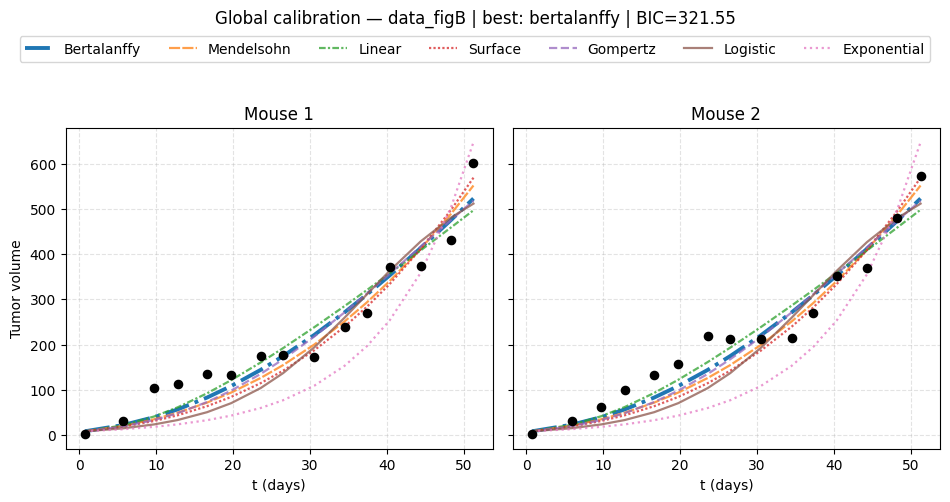


Files saved for group 'data_figB'.



Calibrating (data_figC): 100%|██████████| 7/7 [04:53<00:00, 41.86s/model]


RESULTS FOR GROUP: data_figC

FILES
  Mouse 1: data_frosberg19_fig3C_NOG_CTRL_1.csv | n=13 | t∈[12.78,103.15] | V∈[0.5089,166.9]
  Mouse 2: data_frosberg19_fig3C_NOG_CTRL_2.csv | n=13 | t∈[12.96,103.15] | V∈[0.5089,158.3]
  Mouse 3: data_frosberg19_fig3C_NOG_CTRL_3.csv | n=13 | t∈[12.78,103.15] | V∈[0.5089,118.1]
  Mouse 4: data_frosberg19_fig3C_NOG_CTRL_4.csv | n=13 | t∈[12.96,102.96] | V∈[0.5089,81.42]
  Mouse 5: data_frosberg19_fig3C_NOG_CTRL_5.csv | n=13 | t∈[12.96,103.10] | V∈[0.06503,72.28]

MODEL COMPARISON (sorted by BIC)
      model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE  CV_MAE                                                                                                                                                          diagnostics    ΔBIC   ΔAICc
     linear 609.6196 594.3989 596.3638 -290.1995 20.9926 15.8737   27.0696    58.7806 0.9081 0.8996 0.9009  22.3044 16.3066         f at bound [1e-06, 3338] | 

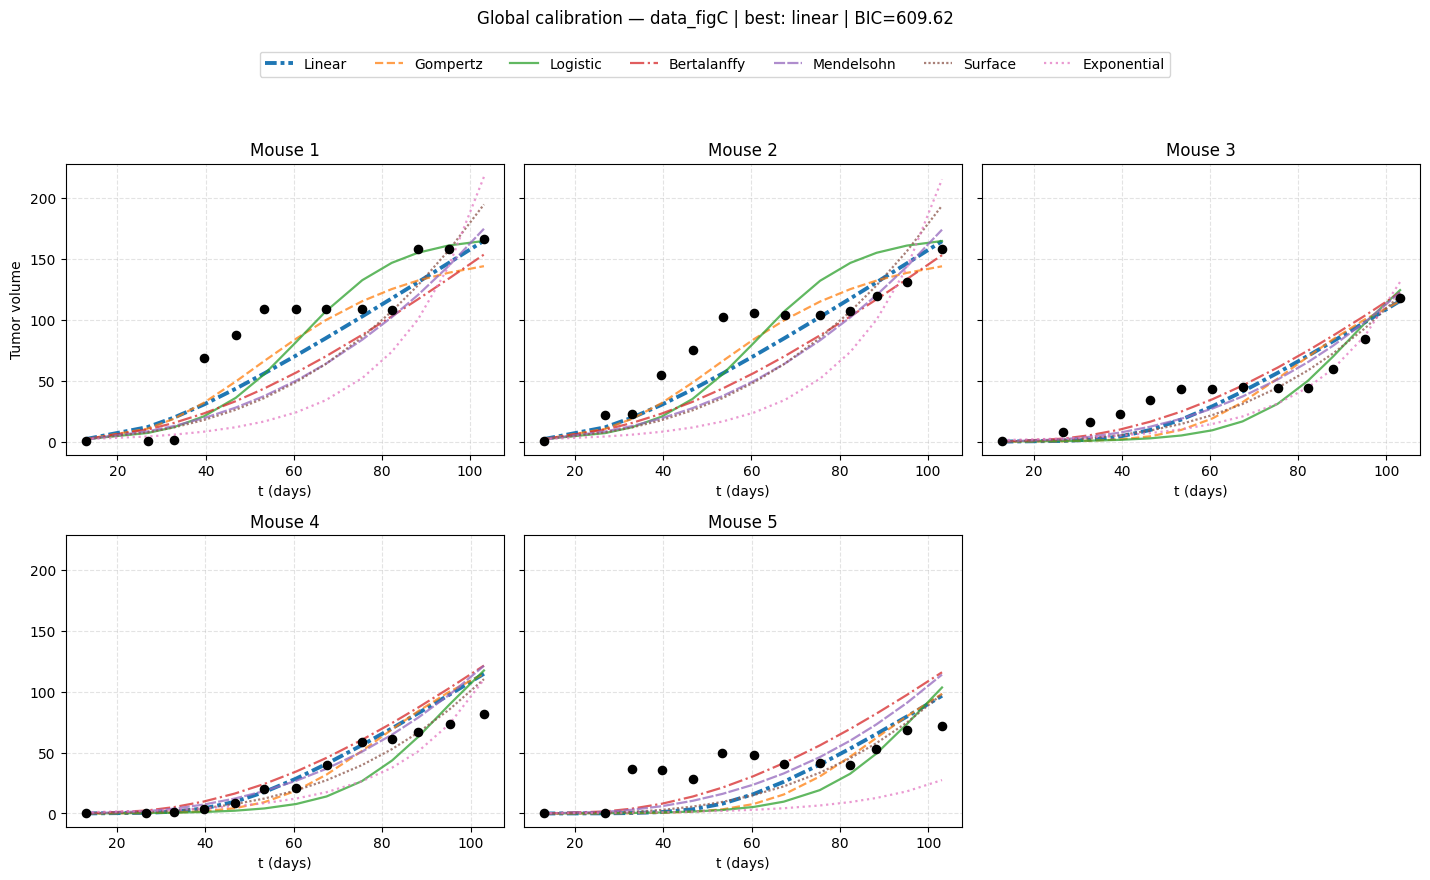


Files saved for group 'data_figC'.



Calibrating (data_figD): 100%|██████████| 7/7 [07:14<00:00, 62.14s/model]


RESULTS FOR GROUP: data_figD

FILES
  Mouse 1: data_frosberg19_fig3D_NOG_CTRL_1.csv | n=19 | t∈[13.09,143.00] | V∈[0.06103,341.9]
  Mouse 2: data_frosberg19_fig3D_NOG_CTRL_2.csv | n=19 | t∈[13.09,142.80] | V∈[0.06103,288.8]
  Mouse 3: data_frosberg19_fig3D_NOG_CTRL_3.csv | n=24 | t∈[13.09,177.04] | V∈[0.06103,143.4]
  Mouse 4: data_frosberg19_fig3D_NOG_CTRL_4.csv | n=26 | t∈[13.09,190.74] | V∈[0.06103,173.4]
  Mouse 5: data_frosberg19_fig3D_NOG_CTRL_5.csv | n=25 | t∈[12.89,190.94] | V∈[0.9925,68.96]
  Mouse 6: data_frosberg19_fig3D_NOG_CTRL_6.csv | n=26 | t∈[13.09,190.94] | V∈[0.06103,40.98]

MODEL COMPARISON (sorted by BIC)
      model       BIC       AIC      AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE   CV_MAE                                                                                                                                                                                                                                                

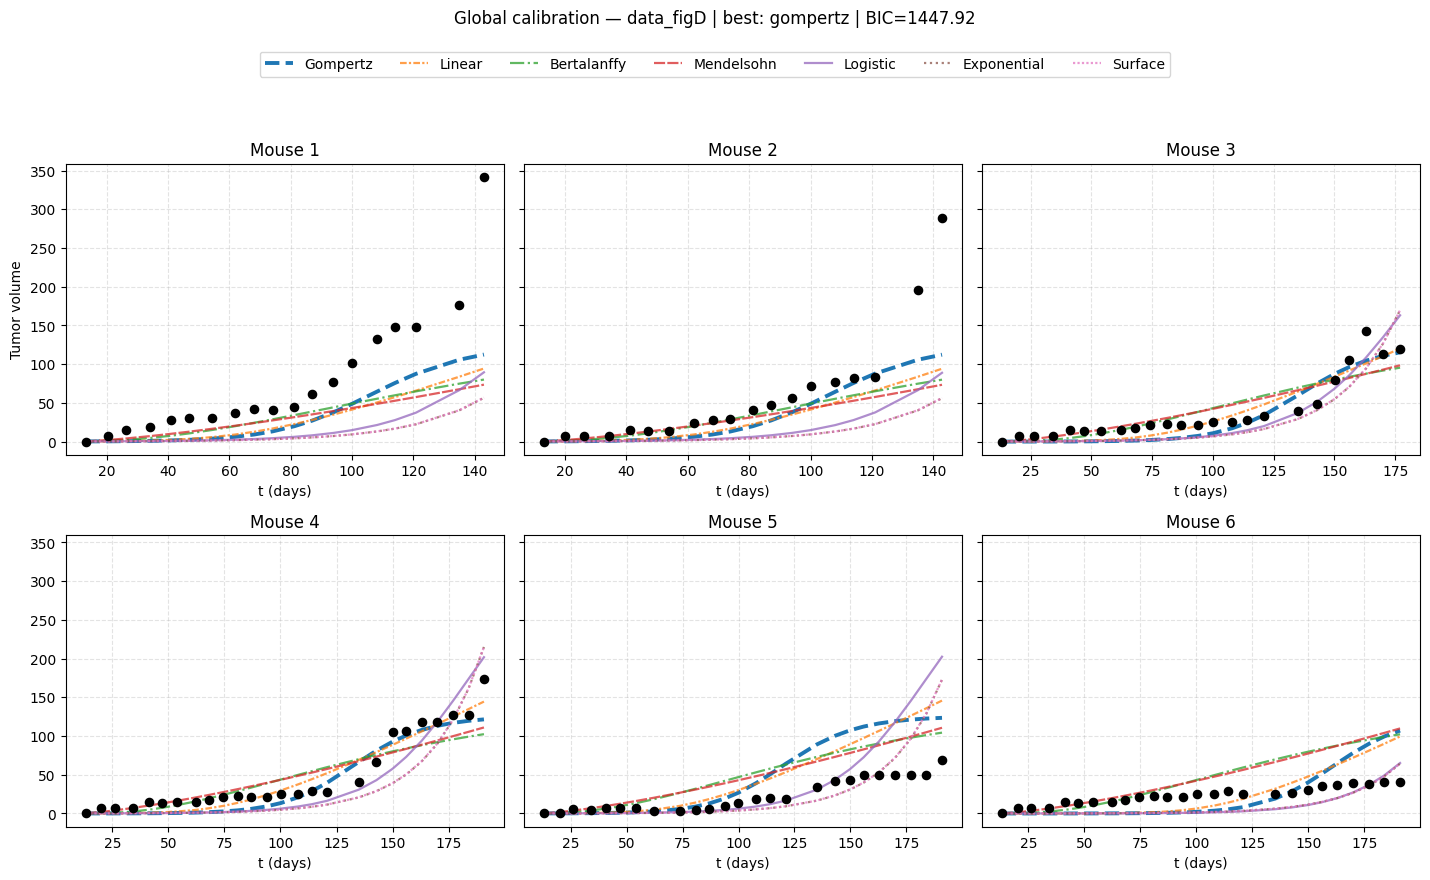


Files saved for group 'data_figD'.

Done.


In [13]:
output_dir = ensure_output_dir(data_root)
print(f"Output folder: {output_dir}\n")
all_results = {}

for gi, (group_name, gd) in enumerate(grouped_data.items()):
    filepaths, datasets = gd["filepaths"], gd["datasets"]
    results = []
    for mi, model in enumerate(tqdm(MODELS, desc=f"Calibrating ({group_name})", unit="model")):
        try:
            results.append(calibrate_global_model(model, datasets,
                                                  seed=RANDOM_SEED + 1000*gi + 100*mi))
        except Exception as e:
            print(f"[WARNING] {group_name} | {model} failed: {e}")
    if not results:
        print(f"[WARNING] No calibration succeeded for {group_name}"); continue

    results = attach_validation_to_top_models(results, datasets, RANDOM_SEED + 1000*gi)
    summary_df = build_summary_table(results)
    print(format_group_report(group_name, filepaths, datasets, results, summary_df))

    plot_fits(datasets, results, group_name,
              output_dir / f"calibration_{sanitize_filename(group_name)}.png")
    write_reports(output_dir, group_name, filepaths, datasets, results, summary_df)
    all_results[group_name] = {"results": results, "summary": summary_df}
    print(f"\nFiles saved for group '{group_name}'.\n")

print("Done.")


## 12. How to use with **your own data** (e.g., CAR-T)

Step by step — **without touching the code**, only the configuration and the files:

1. **Name and organize the files** using the same convention:
   - one folder per group, named `data_figX` (e.g., `data_figB`);
   - inside it, one `.csv` per mouse, with two columns (time, volume),
     following the pattern `..._fig3<PANEL>_<GROUP>_<number>.csv`
     (e.g., `data_frosberg19_fig3B_NOG_CART_1.csv`).
2. In the **Configuration** section, change **only** `FILE_GLOB` to match the
   label of your files, for example:
   `FILE_GLOB = "data_frosberg19_fig3*_NOG_CART_*.csv"`.
3. Run the notebook from top to bottom. Done — the same models, metrics, and
   last-point prediction will run for your group.

**If it's running too slow:** lower `MULTISTART_N_STARTS` (e.g., 2), `OPT_MAXITER`
(e.g., 100), and `VALIDATION_TOP_K` (e.g., 1). For the final "polished"
result, raise these values again.

> ⚠️ **Important biological reminder.** These 7 models only describe
> **growth** (curves that increase, eventually saturating). For treated groups
> where the tumor **regresses**, they will fit poorly — that's already an
> informative result on its own ("pure growth doesn't explain the response"), but
> to *model the treatment effect* you need an equation with a treatment
> term, which is a separate stage.

## 13. How to read the results

- **Lowest BIC wins.** Differences of `ΔBIC < 2` indicate a technical tie — it's
  worth also checking AICc, RMSE, and the correlation metrics (PCC/CCC/ICC close
  to 1 = good).
- **Watch the diagnostics.** If the winning model has a parameter "at its bound" or
  a huge $K$, the win might be due to parsimony rather than a real mechanism.
- **Last-point prediction.** A model can fit the past well and still predict the
  future poorly — compare `RMSE` (fit) with `CV_RMSE` (prediction).
- The best model choice **can change from one group to another**: this is
  expected, and reflects different growth phases/dynamics.
